# Projet n°3 : ViT vs CNN

Le but de ce projet est de comparer les performances et le fonctionnement entre les architectures ViT et les architectures CNN.
Les ViT introduit dans "An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale" se base sur l'architecture transformers introduit quelques années plus tôt dans "Attention Is All You Need".

# Summary
1. [Introduction](#section1)
2. [Dataset CIFAR10](#section2)
3. [Dataset Point and road](#section3)
4. [Style Transfert](#section4)
5. [Explainability](#section4)
6. [Conclusion](#section5)


## Introduction <a class="anchor" id="section1"></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random
from PIL import Image, ImageDraw
import math
import torch.nn.functional as F
from torch.utils.data import Dataset


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("execution sur : ", device)

execution sur :  cuda


### Architecture ViT

#### Patch Embedding

On commence par définir le patch embeding. Cela consiste à décomposer l'image en carré de taille patch_size (la valeur proposé dans le papier qui introduit la méthode est 16, utilisé sur des images de taille 224). La patch_size doit donc impérativement êtreun diviseur de la taille de l'image. On a donc $N = \frac{image\_size}{patch\_size}\times 2$ patchs (on multiplie par deux pour la hauteur et la largeur).


Une fois découpé, on projette les patchs dans un espace d'embedding. Il est possible d'utiliser un réseau dense ou une convolution pour cela. Nous avons choisi d'utiliser une convolution. L'idée de cette méthode réside dans le fait que les transformers traitent des séquences de token mais ne sont pas fait pour gérer des structures 2D comme les images (même 3D ici car on a de la couleur). Dans ce formalisme un patch devient un token et une fois projeter par la convolution (ou flatten puis projetter par un réseau Linear) on obtient notre embedding du token.
La taille de l'embedding correpond donc dans notre cas à la profondeur de la couche de convolution.

Finalement, en utilisant une convolution on a juste besoin d'une couche de conv2D d'une profondeur égale à la dimension voulu en embeding. Les kernels de la convolution est de taille des patchs et le stride aussi. Ainsi on applique la convolution sur tout le patch d'un coup et obtenons en sortie une seule valeur (l'embedding du token). Le stride garantie de passer automatiquement au patch suivant.
A la fin on "ecrase" (Flatten) le résultat pour avoir tout en une seule ligne qui servira d'entré à notre réseau.

In [2]:
class PatchEmbedding(nn.Module):
    def __init__(self, patch_size=16, prof=3, emb_dim=768):
        super().__init__()
        self.patch_size = patch_size
        self.emb = nn.Conv2d(prof, emb_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.emb(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x

#### Transformer Encoder
On construit ensuite un block ViT. C'est la structure de base de notre future réseau, elle est similaire à un block transformer encodeur.

L'architecture est la suivante :
- Une couche de normalisation
- Une self attention (multi head attention)
- On ajoute une connection résiduelle (skipped connection) avec l'entré du block.
- On stock l'état interne
- Une couche de normalisation
- Un réseau feed forward, multi layer perceptron.
- On ajoute finalement l'état interne stocké (skipped connection)

On peut enchainer autant de fois ce block que souhaité.

In [3]:
class ViTBlock(nn.Module):
    def __init__(self, emb_dim, num_heads, mult=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(emb_dim)
        self.att = nn.MultiheadAttention(emb_dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(emb_dim)
        self.line = nn.Sequential(
            nn.Linear(emb_dim, int(emb_dim * mult)),
            nn.GELU(),
            nn.Linear(int(emb_dim * mult), emb_dim),
        )

    def forward(self, x):
        x = x + self.att(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.line(self.norm2(x))
        return x

Finalement on construit notre réseau ViT :
- On commence par le patch embedding expliqué précédement.
- On crée nos token de prédiction. Ils sont concaténés avec l'input (patch embedding). Ils passeront à travers tout le réseau en étant modifier à chaque couche. Ces tokens vont permettrent de "représenter" l'ensemble de l'image en fonction de ce que le ViT considère comme pertinant pour sa tache.
- On fait ensuite du positional embedding. A cause de la division en patch on a perdu l'information spacial de l'image. Pour essayer de compenser cette perte d'information on laisse le réseau apprendre à encoder l'information de position des tokens.
On additionne ce positional encoding à l'embedding des tokens.

Cela définie notre Input pour les blocks "transformer". On a donc le patch embedding concaténé avec les tokens de prédiction et additionné avec l'encodage de la position.

- On passe ensuite cet Input en entré pour des blocks transformer encodeur. On fait se succéder autant de block transformer encodeur que souhaité.
- Puis on fini par une couche de normalisation suivie d'une couche fully connected (multi-layer perceptron) pour sortir un vecteur de la taille du nombre de classe pour pouvoir faire la prédiction ensuite.


In [4]:
class ViT(nn.Module):
    def __init__(self, img_size=224, patch_size=16, n_classes=10, emb_dim=768, prof=6, num_heads=12, chan = 3):
        super().__init__()
        self.patch_embed = PatchEmbedding(patch_size, prof=chan, emb_dim=emb_dim)
        self.pred_token = nn.Parameter(torch.zeros(1, 1, emb_dim))
        num_patches = (img_size // patch_size) ** 2
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, emb_dim))
        self.blocks = nn.Sequential(*[ViTBlock(emb_dim, num_heads) for i in range(prof)])
        self.norm = nn.LayerNorm(emb_dim)
        self.head = nn.Linear(emb_dim, n_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        batch_size = x.shape[0]
        pred_token = self.pred_token.expand(batch_size, -1, -1)
        x = torch.cat((pred_token, x), dim=1)
        
        x = x + self.pos_embed
        x = self.blocks(x)
        x = self.norm(x[:, 0])
        x=self.head(x)
        return x

On crée maintenant notre CNN. Pour cela on défini un block composé de :
- Une conv2D (sans stride et avec zeros padding par défaut)
- Une couche Batch normalisation
- Un activation Relu

On construit notre CNN en se basant sur ce block et en s'inspirant de l'achitechture VGG. On répète autant de fois que voulu les couches suivantes dans l'ordre :
- Deux block de convolution et batch expliqué précédement
- Une couche de pooling avec un noyaux de taille deux (donc division de la dimension spaciale des tenseurs par deux)

A chaque répétition de ces couches on double la profondeur des couches de convolution.
Autrement dis, toute les deux couches de convolution, on divise la dimension spaciale par deux (pooling) et on multiplie la profondeur par deux.

A la fin de toute ces couches on écrase le tenseur pour le faire passer dans la partie classifieurs constitué de trois couches fully connected de dimension décroissante.

In [5]:
class CNNblock(nn.Module):
    def __init__(self, in_channels, out_channels, kern_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kern_size, stride, padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(True)
        )
    def forward(self, x):
        return self.conv(x)

class CNN(nn.Module):
    def __init__(self, in_channels = 3, n_classes=10, prof = 3):
        super().__init__()
        layers = []
        in_channels = 3
        out_channels = 32
        
        for i in range(prof):
            layers.append(CNNblock(in_channels, out_channels))
            in_channels = out_channels
            layers.append(CNNblock(in_channels, out_channels))
            layers.append(nn.MaxPool2d(kernel_size=2))
            out_channels *= 2
                
        self.features = nn.Sequential(*layers)
        
        self.classifier = nn.Sequential(
            nn.LazyLinear(128),
            nn.ReLU(True),
            nn.Linear(128, 64),
            nn.ReLU(True),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

Maintenant on définie simplement la boucle d'entrainement et de test qui calculent la loss et l'accuracy dans notre modèle.

In [6]:
def test_loop(model, testloader):
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            preds = model(inputs)
            _, predicted = torch.max(preds.data, 1)
                 
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f'Accuracy sur le set de test : {acc}%')
    return acc

In [12]:
def train_loop(model, epochs, optimizer, criterion, trainloader, name, testloader = None) :
    hist = {"loss" : [], "acc" : [], "acc_test" : []}
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_acc = 0
        num_inf =0
        for _, (inputs, labels) in enumerate(trainloader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            preds = model(inputs)
            loss = criterion(preds, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(preds.data, 1)
            num_inf += labels.size(0)
            running_acc += (predicted == labels).sum().item()

        hist["loss"].append(running_loss/num_inf)
        hist["acc"].append(100 * running_acc / num_inf)
        if testloader:
            # Utilisation de la fonction externe demandée
            test_acc = test_loop(model, testloader)
            hist["acc_test"].append(test_acc)
        print(f'Epoch {epoch + 1}: Loss: {running_loss/num_inf}, Train Acc: {100 * running_acc / num_inf}%')
        
    torch.save(model.state_dict(), name)
    print(f"Model sauvegardé : {name}")
    return hist

On définie une fonction pour tracer l'accuracy et la loss durant l'entrainement.

In [8]:
def plot_train(hist):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(hist["loss"], label='Train Loss', color='red')
    plt.title('Loss en fonction des epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(hist["acc"], label='Train Accuracy', color='red')
    try :
        plt.plot(hist["acc_test"], label='Test Accuracy', color='blue')
    except :
        None
    plt.title('Accuracy en fonction des epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

## Dataset CIFAR10 <a class="anchor" id="section2"></a>

Pour faire nos premières expériementation nous avons choisi le dataset CIFAR10. Nous souhaitions un dataset semblable à des photos pour essayer de faire de la classification d'image sur des images courantes dans la vrai vie. Notre choix idéal aurait bien sûr été imagenet. Cependant imagenet contient plus d'un million d'images 224x224 parmis 1000 classes. Nous n'avons pas la puissance de calcule pour entrainer des modèles dessus (ni même l'espace mémoire pour stocker ce dataset). Il existe des sous dataset d'imagenet mais ils nous parraissaient encore trop ambitieux vis à vis des moyens techniques à notre disposition.

CIFAR10 contient 60000 images parmis 10 classes (avions, voitures, oiseaux, chats, cerfs, chiens, grenouilles, chevaux, navires et camions). Ce sont des images 32x32 donc plus légère à traiter et à stocker. La dataset est suffisament grand pour espérer avoir des résultats intéressant et répond à notre volonté de traiter des images de la vie de tout les jours.

Nous divisons le dataset en 50000 images d'entrainements et 10000 images de test.

In [9]:
batch_size = 64

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False)

classes = ('avion', 'voiture', 'oiseau', 'chat', 'cerf', 'chien', 'grenouille', 'cheval', 'bateau', 'camion')

Dans leur article d'origine, les ViT sont proposer avec un patchsize de 16. Néanmoins cela ne serait pas du tout adapté à ce dataset car les images sont de taille 32, on aurait donc seulement 4 patchs. Des images de tailles 224 en patch de taille 16, implique 2x(224/16) = 2x14 patch. Pour être proche du même ratio il faudrait prendre des patchs de taille 2. Néanmoins pour réduire un peu le temps de calcul tout en restant proche (pour garantir de bon résultat) nous avons choisi des patchs de taille 4. La dimension de l'espace d'embedding est choisi à 128. Il n'y a pas de règle pour choisir cette dimension, étant donné de que nos images d'origine sont assez petite nous avons réduit la taille de cet espace par rapport à ce qui était proposer pour l'architecture initialement. Nous choisissons d'avoir 4 blocks type transformer. Etant donnée la taille d'origine de l'image il ne nous semblait pas nécéssaire d'en mettre plus.
Le nombre de tête d'attention dans les couches multihead attention a pour seul contrainte technique d'être un diviseur de la dimension d'embedding, ici nous avons arbitrairement choisie 8, ce qui fait que chaque tête a une dimension 16.

In [20]:
model = ViT(
    img_size=32, 
    patch_size=4, 
    n_classes=10, 
    emb_dim=128, 
    prof=4, 
    num_heads=8
).to(device)

epochs = 20
learning_rate = 1e-4
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

On fixe le learning_rate à $10^{-4}$ et on lance l'entraintement sur 30 epochs. Etant donnée que le dataset contient 50000 d'entrainement, au délà de 30 epochs nous avons peur de sûr-entrainer le modèle.

In [21]:
hist = train_loop(model, epochs, optimizer, criterion, trainloader, "vit_cifar_10.pth", testloader)

Accuracy sur le set de test : 44.9%
Epoch 1: Loss: 0.026698124804496765, Train Acc: 37.016%, Test Acc: 44.9%
Accuracy sur le set de test : 51.4%
Epoch 2: Loss: 0.02155096072435379, Train Acc: 50.076%, Test Acc: 51.4%
Accuracy sur le set de test : 56.6%
Epoch 3: Loss: 0.019124252465963363, Train Acc: 56.098%, Test Acc: 56.6%
Accuracy sur le set de test : 57.8%
Epoch 4: Loss: 0.01752242909312248, Train Acc: 59.706%, Test Acc: 57.8%
Accuracy sur le set de test : 60.77%
Epoch 5: Loss: 0.016220861127376557, Train Acc: 62.756%, Test Acc: 60.77%
Accuracy sur le set de test : 62.55%
Epoch 6: Loss: 0.015082909668684006, Train Acc: 65.184%, Test Acc: 62.55%
Accuracy sur le set de test : 62.92%
Epoch 7: Loss: 0.014068693051338196, Train Acc: 67.854%, Test Acc: 62.92%
Accuracy sur le set de test : 63.61%
Epoch 8: Loss: 0.013043167255520821, Train Acc: 70.18%, Test Acc: 63.61%
Accuracy sur le set de test : 63.27%
Epoch 9: Loss: 0.012136974521875381, Train Acc: 72.092%, Test Acc: 63.27%
Accuracy sur

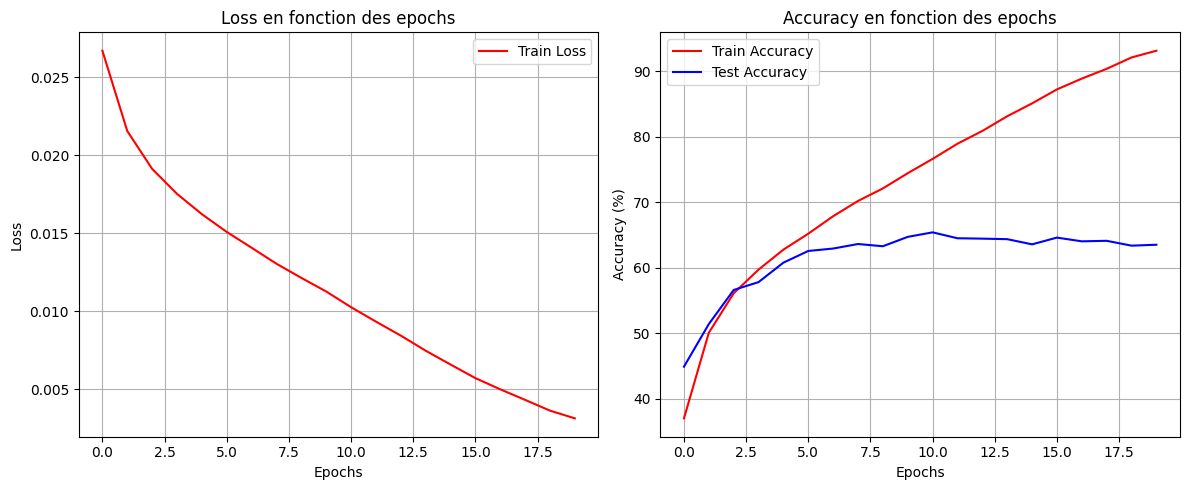

In [24]:
plot_train(hist)

In [26]:
modelvit_cifar = ViT(img_size=32, patch_size=4, n_classes=10, emb_dim=128, prof=4, num_heads=8).to(device)
PATH = "vit_cifar10.pth"
modelvit_cifar.load_state_dict(torch.load(PATH, map_location=device))
modelvit_cifar.eval()
acc_vit_cifar = test_loop(modelvit_cifar, testloader)
       

Accuracy sur le set de test : 62.3%


Comme pour le ViT on définie notre CNN pour travailer sur CIFAR10. On choisi 4 de profondeurs (soit 8 couche de convolution au total) car les images sont de petites tailles donc il n'est pas nécéssaire d'aller au delà.

In [28]:
model = CNN(n_classes=10, prof=4).to(device)
epochs = 20
learning_rate = 1e-3
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

hist = train_loop(model, epochs, optimizer, criterion, trainloader, "cnn_cifar10.pth", testloader)

Accuracy sur le set de test : 64.32%
Epoch 1: Loss: 0.02062910296678543, Train Acc: 50.806%, Test Acc: 64.32%
Accuracy sur le set de test : 74.35%
Epoch 2: Loss: 0.013023300682902337, Train Acc: 70.584%, Test Acc: 74.35%
Accuracy sur le set de test : 78.53%
Epoch 3: Loss: 0.009988156849741936, Train Acc: 77.754%, Test Acc: 78.53%
Accuracy sur le set de test : 79.02%
Epoch 4: Loss: 0.00801770318210125, Train Acc: 82.244%, Test Acc: 79.02%
Accuracy sur le set de test : 79.45%
Epoch 5: Loss: 0.0068110822039842605, Train Acc: 84.912%, Test Acc: 79.45%
Accuracy sur le set de test : 82.75%
Epoch 6: Loss: 0.005626659114658833, Train Acc: 87.596%, Test Acc: 82.75%
Accuracy sur le set de test : 82.66%
Epoch 7: Loss: 0.004569254057183862, Train Acc: 89.918%, Test Acc: 82.66%
Accuracy sur le set de test : 82.78%
Epoch 8: Loss: 0.003795586943328381, Train Acc: 91.464%, Test Acc: 82.78%
Accuracy sur le set de test : 82.71%
Epoch 9: Loss: 0.0029970183660835027, Train Acc: 93.468%, Test Acc: 82.71%
A

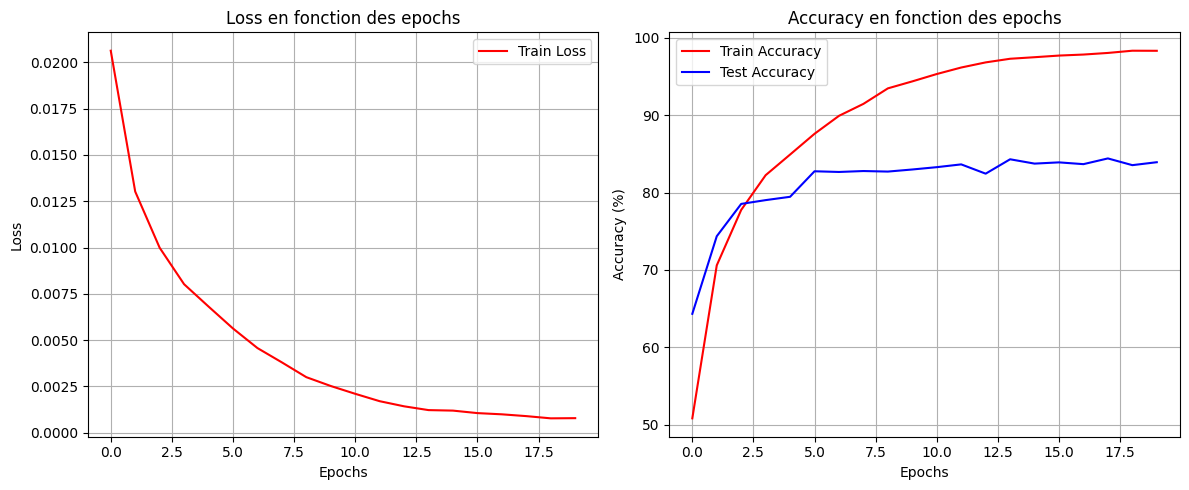

In [29]:
plot_train(hist)

In [30]:
modelcnn_cifar = CNN(n_classes=10, prof=4).to(device)
PATH = "cnn_cifar10.pth"
modelcnn_cifar.load_state_dict(torch.load(PATH, map_location=device))
modelcnn_cifar.eval()
acc_vit_cifar = test_loop(modelcnn_cifar, testloader)

Accuracy sur le set de test : 84.1%


On a ici un "petit" dataset. On sais que les ViT sont performant sur les très grand dataset (plusieurs million/centaine de million d'image), c'est déjà une remarque qui était faite lors de l'introduction de l'architecture dans le premier papier.

On remarque bien ici que l'accuracy de test stagne très rapidement pour le ViT à un niveau relativement bas (autour de 63% d'accuracy).
A l'inverse le CNN est plus adapté sur des datasets plus petit, on voit ici qu'il atteint 84% d'accuracy en set de test.

Par ailleur, il est connu que les ViT sont moins performant sur les petites image ce qui est le cas ici.

# Tiny imagenet

In [19]:
#!wget http://cs231n.stanford.edu/tiny-imagenet-200.zip
#!unzip -q tiny-imagenet-200.zip

In [20]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.ImageFolder(root='tiny-imagenet-200/train', transform=transform)
test_dataset  = datasets.ImageFolder(root='tiny-imagenet-200/val', transform=transform)

trainloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
testloader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Nombre d'images d'entraînement : {len(train_dataset)}")
print(f"Nombre de classes : {len(train_dataset.classes)}")

Nombre d'images d'entraînement : 100000
Nombre de classes : 200


In [21]:
model = ViT(img_size=64, patch_size=8, n_classes=200, prof=4, num_heads=8).to(device)
epochs = 100
learning_rate = 1e-4
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

#hist = train_loop(model, epochs, optimizer, criterion, trainloader, "vit_imnet.pth")

In [22]:
#plot_train(hist)

In [23]:
modelvit_imnet = ViT(img_size=64, patch_size=8, n_classes=200, prof=4, num_heads=8).to(device)
PATH = "vit_imnet.pth"
modelvit_imnet.load_state_dict(torch.load(PATH, map_location=device))
modelvit_imnet.eval()
#test_loop(modelvit_imnet, testloader)

ViT(
  (patch_embed): PatchEmbedding(
    (emb): Conv2d(3, 768, kernel_size=(8, 8), stride=(8, 8))
  )
  (blocks): Sequential(
    (0): ViTBlock(
      (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (att): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
      )
      (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (line): Sequential(
        (0): Linear(in_features=768, out_features=3072, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=3072, out_features=768, bias=True)
      )
    )
    (1): ViTBlock(
      (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (att): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
      )
      (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (line): Sequential(
        (0): Linear(in_features=768, out_fe

In [24]:
model = CNN(n_classes=200, prof=6)
epochs = 200
learning_rate = 1e-4
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

#hist = train_loop(model, epochs, optimizer, criterion, trainloader, "cnn_imnet.pth")
#plot_train(hist)

In [25]:
modelcnn_imnet = CNN(n_classes=200, prof=6).to(device)
PATH = "cnn_imnet.pth"
modelcnn_imnet.load_state_dict(torch.load(PATH, map_location=device))
modelcnn_imnet.eval()
#test_loop(modelcnn_imnet, testloader)

CNN(
  (features): Sequential(
    (0): CNNblock(
      (conv): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (1): CNNblock(
      (conv): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): CNNblock(
      (conv): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (4): CNNblock(
      (conv): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stri

## Dataset Point <a class="anchor" id="section3"></a>

L'idée maintenant, plutôt que d'entrainer des modèles sur d'autre dataset classique dérivé d'imagenet ou autre, va être d'essayer de mettre en lumière les différences structurelle entre les ViT et les CNN.

Pour cela nous allons créer notre propre jeu de donnée. Il s'agira d'un problème de classification binaire. On a des images contenant deux points rouges. On trace plusieurs chemins de manière aléatoire sur cette image. La question à laquelle on souhaite répondre est : existe il un chemin qui relie les deux points ou non.
La fonction de création du data est assez longue (est a été pofiné avec l'aide d'IA générative pour corriger les bugs). Elle consiste à :
- Placer les deux points sur l'image
- Choisir aléatoirement un label (1 : les points sont relier, 0 : les points ne sont pas relier)
- Créer une matrice pour enregistrer les zones déjà occupé de l'image (ici tout l'enjeux est de ne pas créer involontairement des chemins qui se croisent si le label est 0). Pour évité tout problème, on crée une marge de sécurité de 1 pixel pour s'assurer qu'il n'y aura pas de croisement.
- Créer des chemins de manière itérative avec la procédure : on choisie une direction aléatoirement -> on vérifie qu'il n'y a rien dans cette direction pour nous bloquer -> on avance de 4 pixels dans la direction.
On répète ces opérations autant de fois que voulu pour autant de chemin qui souhaité. Chaque chemin peut partir aléatoirement de l'un des deux points ou d'un pixel non occupé.
- Si le label est 1, alors on créer un chemin avec la procédure précédante en partant d'un des deux points, puis à la fin de ce chemin on trace une droite qui le relie à l'autre point.


Notre intuition est que, le CNN, grace à sa capacité à traiter les données de manière spacial va être capable de suivre les chemins pour détecter si les points sont relier. A l'inverse, le ViT risque d'être plus en difficulté car l'encodage positionel est compliqué à apprendre et risque de ne pas être suffisant pour réussir la tache. En effet le ViT lors de l'étape de tokenization perd l'information spacial.

On s'attend donc à obtenir les résultats suivant :
- Le CNN atteindrait rapidement d'excellent score en test car la tache serait simple pour son architecture.
- Le ViT serait beaucoup plus long à converger et n'arriverais pas à atteindre le même niveau de précision que le CNN.

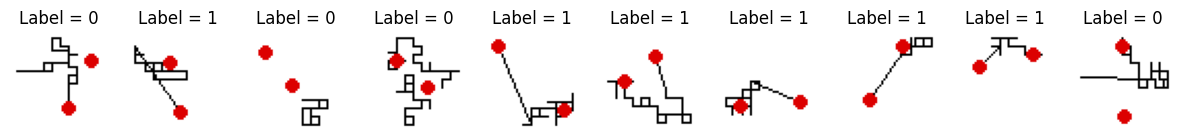

In [4]:
def generate_samepath_image_color(
    img_size=64,
    n_paths=3,
    path_size=40,
    min_distance_ratio=0.33,
    r=3
):
    img = Image.new("RGB", (img_size, img_size), (255, 255, 255))
    draw = ImageDraw.Draw(img)
    
    min_dist = img_size * min_distance_ratio
    while True:
        p1 = (random.randint(7, img_size-7), random.randint(7, img_size-7))
        p2 = (random.randint(7, img_size-7), random.randint(7, img_size-7))
        if math.dist(p1, p2) >= min_dist:
            break

    label = random.choice([0, 1])

    # Masque pour vérifier les pixels occupés
    mask = np.zeros((img_size, img_size), dtype=int)

    mask[p1[1]-r-2:p1[1]+r+2, p1[0]-r-2:p1[0]+r+2] = 1
    mask[ p2[1]-r-2:p2[1]+r+2, p2[0]-r-2:p2[0]+r+2] = 2

    def random_path(start, end=None, path_id=3, tl = False):
        pts = [start]
        if pts[-1] in [p1] :
            allow_start = 1
        elif pts[-1] in [p2] :
            allow_start = 2
        else : allow_start = 0

        for _ in range(path_size):
            directions = [(1,0),(-1,0),(0,1),(0,-1)]
            random.shuffle(directions)
            for dx, dy in directions:
                x_new = np.clip(pts[-1][0] + dx * 4, 3, img_size-3)
                y_new = np.clip(pts[-1][1] + dy * 4, 3, img_size-3)

                # Vérifie tous les points sur le segment
                x_line = np.linspace(pts[-1][0], x_new, num=5, dtype=int)
                y_line = np.linspace(pts[-1][1], y_new, num=5, dtype=int)

                
                if all(mask[int(y_line[i]), int(x_line[i])] in [0, path_id, allow_start] for i in range(5)):
                    pts.append((x_new, y_new))
                    # Marque le masque **après validation**
                    for xi, yi in zip(x_line, y_line):
                        size = 2
                        x_min = max(0, xi-size)
                        x_max = min(img_size-1, xi+size)
                        y_min = max(0, yi-size)
                        y_max = min(img_size-1, yi+size)
                        mask[y_min:y_max+1, x_min:x_max+1] = path_id
                    break
        if end is not None:
                x0, y0 = pts[-1]
                x1, y1 = end
                # créer un segment entre le dernier point et end
                n_points = max(abs(x1 - x0), abs(y1 - y0)) + 1
                x_line = np.linspace(x0, x1, num=n_points, dtype=int)
                y_line = np.linspace(y0, y1, num=n_points, dtype=int)
                if tl :
                  for xi, yi in zip(x_line, y_line):
                      size = 2 
                      x_min = max(0, xi-size)
                      x_max = min(img_size-1, xi+size)
                      y_min = max(0, yi-size)
                      y_max = min(img_size-1, yi+size)
                      mask[y_min:y_max+1, x_min:x_max+1] = path_id
                  pts.append(end)

                elif all(mask[y_line[i], x_line[i]] in [0, path_id] or (i == 0 and allow_start) for i in range(n_points)) :
                  for xi, yi in zip(x_line, y_line):
                      size = 2 
                      x_min = max(0, xi-size)
                      x_max = min(img_size-1, xi+size)
                      y_min = max(0, yi-size)
                      y_max = min(img_size-1, yi+size)
                      mask[y_min:y_max+1, x_min:x_max+1] = path_id
                  pts.append(end)

        return pts
    path_counter = 3
    # Ligne directe entre p1 et p2 si label == 1
    if label == 1:
        path = random_path(p1, p2, path_counter, tl = True)
        draw.line(path, fill=(0, 0, 0), width=1)
        path_counter += 1

    # Faux chemins
    for _ in range(random.randint(1, n_paths)):
        s = (random.randint(3, img_size-3), random.randint(3, img_size-3))       
        pdep = random.choice([p1, p2, s])
        e = (random.randint(3, img_size-3), random.randint(3, img_size-3))
        path = random_path(pdep, e, path_id= path_counter)
        draw.line(path, fill=(0, 0, 0), width=1)
        path_counter +=1

    # Dessine les points rouges
    for p in [p1, p2]:
        draw.ellipse(
            [p[0]-r, p[1]-r, p[0]+r, p[1]+r],
            fill=(220, 0, 0)
        )
    return np.array(img), label

n = 10
plt.figure(figsize=(15, 3))
for i in range(n):
    img, label = generate_samepath_image_color(img_size = 48, r=3)
    plt.subplot(1, n, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label = {label}")

plt.show()


Pour tester ces réseaux on va les entrainers sur 50000 images (statistiquement environ 25000 de chaques classes) et les testers sur 10000 images (satistiquement environ 5000 de chaque). 

Etant donnée que nous créons le dataset nous même avec une fonction, on pourrait le prendre aussi grand que l'on souhaite, on se limite ici à 50000 images d'entrainement pour des questions de temps d'entrainement.

In [ ]:

class MyDataset(Dataset):
    def __init__(self, n_samples, size, path_size, r):
        self.n_samples = n_samples
        self.img_size = size
        self.path_size = path_size
        self.r = r

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        img, label = generate_samepath_image_color(img_size=self.img_size, path_size=self.path_size, r=self.r)
        img = torch.tensor(img, dtype=torch.float32).permute(2,0,1) / 255.0
        label = torch.tensor(label, dtype=torch.long)
        return img, label

trainset = MyDataset(n_samples=50000, size=32, path_size=20, r=2)
testset = MyDataset(n_samples=10000, size=32, path_size=20, r=2)

trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
testloader = DataLoader(testset, batch_size=32, shuffle=False)


Cette fois ci il y a moins de détail à suivre sur les images, on choisie donc de ne prendre que trois couche "transformer" en profondeur. Cependant nous augmentont la taille d'embedding par rapport à CIFAR pour voir si cela permet au réseau de mieux de capter les relations dans l'image. On ne touche pas à la taille de patch car on a des images de tailles similaires à CIFAR10.
On entraine sur 50 epochs, plus que sur CIFAR10 car les données sont selon ce que nous avons expliquer précédement plus compliqué pour le ViT.

In [ ]:
img_size = 32

model = ViT(img_size=img_size, patch_size=4, n_classes=2, prof=3, num_heads=8).to(device)
epochs = 50
learning_rate = 1e-4
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

hist = train_loop(model, epochs, optimizer, criterion, trainloader, "vit_point.pth", testloader)
plot_train(hist)

Sur 50 epochs on obtient la loss et accuracy suivant :

![Loss et acc du ViT sur le dataset point](https://drive.google.com/thumbnail?id=1F_qPE4pXgtBUUNsIIWTWVd9HIAkQ0F3G&sz=w1000)

On met également moins de profondeur pour le CNN car la tache est sensé être assez simple pour lui et qu'il y a peut d'information différente à saisir sur les images (seulement deux points et des lignes monocolore).

On décide de mettre 50 epochs, cela n'est probablement pas nécéssaire de mettre autant. Une dizaine d'epoch devrait être suffisante, néanmoins cela est l'occasion de voir si le CNN peut overfitt sur ce genre de donnée très particulière.

In [ ]:
model = CNN(n_classes=2, prof=3)
epochs = 50
learning_rate = 1e-4
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

hist = train_loop(model, epochs, optimizer, criterion, trainloader, "cnn_point.pth", testloader)
plot_train(hist)

Sur 50 epochs on obtient la loss et accuracy suivant :

![Loss et acc du CNN sur le dataset point](https://drive.google.com/thumbnail?id=150yuw4Gn8j2ZhkRvVPr3VWpbrn-0dAjV&sz=w1000)



On observe exactement ce qui était anticipé !

- Le CNN obtient très rapidement de très bon résultat (99% d'accuracy test et train au bout de quelques epochs). On constate qu'il n'y a pas d'overfitting car la courbe de test reste croissante et suis la courbe d'accuracy.
- Le ViT semble bien avoir du mal à apprendre sur ces données, son accuracy monte particulièrement lentement, on remarque qu'il n'a pas encore converger, il serait intéressant de l'entrainer sur plus d'epoch, nous avons malheureusement sous estimé le nombre d'epoch nécessaire à son apprentissage.

Cet exemple de dataset est donc une très bonne illustration des défauts de l'architecture. La tokenization de l'image détruit la structure spaciale. La position encoding est très difficile à apprendre ce qui rend cette architecture moins performante pour des taches nécessitant une forte compréhension de la dimension spaciale.

## Style transfert <a class="anchor" id="section4"></a>

Le but de cette partie n'est pas d'entrainer un nouveau réseau de neuronne mais plutôt de mettre en lumière les différences intrinsèques de fonctionnement entre CNN et ViT.
Nous avons utiliser des réseaux pré-entrainer pour pouvoir travailler sur des images variées et de grande taille (224x224). Cela nous permet plus de liberté pour la mise en lumière des différences de fonctionnement mais il est bien sûr possible de ré-entrainer nous même un réseau sur un jeu de donnée approprié pour obtenir ces même résultats.

Nous savons que, par l'application de convolution, les CNNs sont particulièrement sensible à la "granularité" locale de l'image. Ils sont capable d'exploiter la "texture" des éléments présent sur l'image pour faire leur classification. A l'inverse, les ViT utilises des couches d'attentions sur les tokens (issu des patchs de l'image). Le fait de passer sous forme de token avant de passer dans les couches d'attention a tendance à rendre le réseau moins sensible aux texture local de l'image. Le ViT va plutôt exploiter l'attention entre les différents token (différente zone de l'image) pour faire sa classification.

Nous avons donc voulu reprendre le concept de transfert de style que nous avons étudier en cours d'Image. Nous avons repris le TP que nous avions fait sur le sujet et l'avons : conertie en pytorch (le TP utilisait tensorflow) et raccourcie légèrement car celui si était à but pédagique, nous avons garder seulement le nécessaire pour une inférence (nous avons utilisé l'aide d'une IA générative pour ces taches afin d'avoir un code propre et efficace).

Notre intuition est la suivante : Puisque le CNN est très sensbile à la texture de l'image, alors un transfert de style devrait faire brutalement chuter la probabilité de sortie. A l'inverse le ViT devrait être beaucoup plus robuste au transfert de style.

Pour faire le transfert de style nous allons utiliser les caractéristiques extraite par un VGG19 pré-entrainé.
Le nombre d'étape de transfert est très important, si il est trop élevé alors l'image de contenu sera trop modifier justifiant une "erreur" de classification pour les deux modèles (ViT et CNN). Mais il doit tout de même être assez élever pour qu'il y ait une modification notable de l'image. Nous avons pris 200 étapes de transfert qui donne un bon compromis.

Nous allons évaluer les réseaux VGG19 et ViT_B_16, tout les deux entrainés sur imagenet. En travaillent sur des réseaux entrainés sur d'aussi grande base de donnée et autant de classe, on a beaucoup de choix pour les images de style et de contenu.
Voici un exemple avec une image de phare en contenu et une image de paon en style. Le phare est un type d'image présentant beaucoup d'information structurelle, ce n'est pas une classe qui, humainement parlant, a tendance à avoir beaucoup de texture à détecter. Pour le style le paon avec sa queu très coloré représente un contenu de style idéal pour perturber l'image.

Utilisation de : cuda
Début de l'optimisation...
Étape 100/200 | Loss: 8166456320.0000
Étape 200/200 | Loss: 2618910720.0000


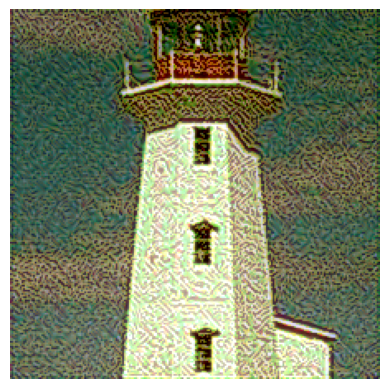

In [ ]:
# Chargement du VGG19 (on ne garde que les couches de caractéristiques)
vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device).eval()

# On gèle les paramètres du réseau
for param in vgg.parameters():
    param.requires_grad_(False)

def load_image(img_path, max_size=400, shape=None):
    image = Image.open(img_path).convert('RGB')
    
    size = max_size if max(image.size) > max_size else max(image.size)
    if shape is not None:
        size = shape
        
    in_transform = transforms.Compose([
        transforms.Resize(size),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    ])

    image = in_transform(image).unsqueeze(0)
    return image.to(device)

def im_convert(tensor):
    image = tensor.to("cpu").clone().detach()
    image = image.numpy().squeeze().transpose(1, 2, 0)
    image = image * np.array((0.229, 0.224, 0.225)) + np.array((0.485, 0.456, 0.406))
    return image.clip(0, 1)

# 3. Définition du modèle et des fonctions de style
vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device).eval()
for param in vgg.parameters():
    param.requires_grad_(False)

def get_features(image, model):
    layers = {'0': 'conv1_1', '5': 'conv2_1', '10': 'conv3_1', 
              '19': 'conv4_1', '21': 'conv4_2', '28': 'conv5_1'}
    features = {}
    x = image
    for name, layer in model._modules.items():
        x = layer(x)
        if name in layers:
            features[layers[name]] = x
    return features

def gram_matrix(tensor):
    _, d, h, w = tensor.size()
    tensor = tensor.view(d, h * w)
    return torch.mm(tensor, tensor.t())


content_img = load_image('phare.jpg')
style_img = load_image('paon.jpg', shape=content_img.shape[-2:])

content_features = get_features(content_img, vgg)
style_features = get_features(style_img, vgg)
style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}

target = content_img.clone().requires_grad_(True).to(device)

style_weights = {'conv1_1': 1.0, 'conv2_1': 0.75, 'conv3_1': 0.2, 
                 'conv4_1': 0.2, 'conv5_1': 0.2}

optimizer = optim.Adam([target], lr=0.01) # Augmentation du LR pour plus de rapidité
steps = 200 

print("Début de l'optimisation...")
for i in range(1, steps + 1):
    target_features = get_features(target, vgg)
    
    # Calcul perte Contenu
    content_loss = torch.mean((target_features['conv4_2'] - content_features['conv4_2'])**2)
    
    # Calcul perte Style
    style_loss = 0
    for layer in style_weights:
        target_gram = gram_matrix(target_features[layer])
        style_gram = style_grams[layer]
        layer_style_loss = style_weights[layer] * torch.mean((target_gram - style_gram)**2)
        style_loss += layer_style_loss / (target_gram.shape[1] * target_gram.shape[0])

    # Pondération totale
    total_loss = 1e3 * content_loss + 1e6 * style_loss
    
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if i % 100 == 0:
        print(f"Étape {i}/{steps} | Loss: {total_loss.item():.4f}")

# Affichage du résultat final
plt.imshow(im_convert(target))
plt.axis('off')
plt.show()

On observe ici notre image de phare modifier avec un style de paon. Maintenant nous allons voir à quel points nos réseaux ViT et CNN sont effecter par ce changement.
Nous allons observer la probabilité sur les deux images initiales puis les comparers à celle de l'image modifier.

In [ ]:

def get_clean_image(tensor):
    img = tensor.to("cpu").clone().detach().squeeze(0)
    # Dénormalisation VGG
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    img = inv_normalize(img)
    img = torch.clamp(img, 0, 1)
    return transforms.ToPILImage()(img)
# 1. Préparation des modèles et des catégories
vgg_full = models.vgg19(weights=models.VGG19_Weights.DEFAULT).to(device).eval()
vit_full = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT).to(device).eval()

vgg_weights = models.VGG19_Weights.DEFAULT
vit_weights = models.ViT_B_16_Weights.DEFAULT
categories = vgg_weights.meta["categories"] # Les deux utilisent ImageNet-1K

target_names = ['beacon', 'peacock']#['chain mail', 'monastery']
target_indices = [categories.index(name) for name in target_names]

# 2. Fonction d'analyse
def analyze_image(img_tensor, title):
    # Prétraitement spécifique pour chaque modèle (redimensionnement à 224x224)
    img_vgg = vgg_weights.transforms()(get_clean_image(img_tensor)).unsqueeze(0).to(device)
    img_vit = vit_weights.transforms()(get_clean_image(img_tensor)).unsqueeze(0).to(device)
    
    with torch.no_grad():
        out_vgg = vgg_full(img_vgg)
        out_vit = vit_full(img_vit)
        
        prob_vgg = F.softmax(out_vgg[0], dim=0)
        prob_vit = F.softmax(out_vit[0], dim=0)
        
    print(f"\n--- Analyse : {title} ---")
    print(f"{'Classe':<15} | {'VGG19 (%)':<12} | {'ViT (%)':<12}")
    print("-" * 45)
    for i, name in zip(target_indices, target_names):
        print(f"{name:<15} | {prob_vgg[i]*100:>10.2f}% | {prob_vit[i]*100:>10.2f}%")

# 3. Exécution sur les 3 images
# Note : on utilise les tenseurs originaux avant d'afficher
analyze_image(content_img, "Image de Contenu")
analyze_image(style_img, "Image de Style")
analyze_image(target, "Image Stylisée")


--- Analyse : Image de Contenu ---
Classe          | VGG19 (%)    | ViT (%)     
---------------------------------------------
beacon          |      99.84% |      86.20%
peacock         |       0.00% |       0.01%

--- Analyse : Image de Style ---
Classe          | VGG19 (%)    | ViT (%)     
---------------------------------------------
beacon          |       0.00% |       0.02%
peacock         |     100.00% |      78.84%

--- Analyse : Image Stylisée ---
Classe          | VGG19 (%)    | ViT (%)     
---------------------------------------------
beacon          |       0.06% |      81.02%
peacock         |       0.00% |       0.02%


Pour les images initiales, le paon et le phare sont tout les deux bien classifié (avec beaucoup de certitude au vu des probabilité de sortie). C'est un bon départ !

Maintenant obervont les prédictions pour l'image modifier. On remarque que le ViT est très peu affecter par ce changement, la probabilité d'être un phare reste très élever et a seulement baissé de 0,05.
Concernant le CNN il est passer de 99,84% de probabilité d'être un phare à 0.06%, il ne prédit plus du tout la bonne classe. On aurait pu s'attendre à ce qu'il prédise maintenant un paon mais ce n'est pas le cas. En fait le transfert de style donne un mélange entre le style du phare et du paon ce qui perd complètement le CNN.

C'est exactement le genre de résultat que l'on espérer voir. Le ViT par sa structure avec des couches d'attention est beaucoup moins sensible à la texte des objets que les CNN qui se base énormément dessus.

(Nous avons également tester sur une image de monastere en contenu avec une image de cote de maille en style et obtenons les mêmes conclusions)